In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import QuantileRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
from data_utils import RBFFeatureEngineerExpert, pinball_loss, DefaultFeatureEngineerExpert, PrimaryFeatureEngineerExpert
from sklearn.model_selection import TimeSeriesSplit
from data_utils import AdaptiveKalman
import lightgbm as lgb
from sklearn.metrics import mean_pinball_loss

In [2]:
!pip show scikit-learn # Version: 1.8.0, otherwise please run the next cell

Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: /home/yaroslav/miniconda3/lib/python3.13/site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: 


In [ ]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.8.0
# Ensure the reproducibility
# Our machine was using scikit-learn 1.8.0, colab defaults to 1.6.1

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)


In [3]:
# Ignore some warnings
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-darkgrid')
QUANTILE = 0.8
ALPHA = 0.0004 # Value chosen by CV

In [4]:
train = pd.read_csv("Data/net-load-forecasting-during-soberty-period/train.csv")
test = pd.read_csv("Data/net-load-forecasting-during-soberty-period/test.csv")

# Train on the data before COVID
mask_train = train["Date"] < "2020-01-01"
mask_cal = (train["Date"] >= "2020-01-01") & (train["Date"] < "2020-03-01")
mask_val = train["Date"] >= "2020-03-01"

df_train_raw = train[mask_train]
df_cal_raw = train[mask_cal]
df_val_raw = train[mask_val]

exclude = ["Date","Net_demand","Load","Solar_power", 'Wind',"Wind_power","WeekDays","Id","Usage","Year","Month"]
fe = RBFFeatureEngineerExpert().fit(df_train_raw)

X_train = fe.transform(df_train_raw)
X_cal = fe.transform(df_cal_raw)
X_val = fe.transform(df_val_raw)

y_train = df_train_raw['Net_demand']
y_cal= df_cal_raw['Net_demand']
y_val = df_val_raw['Net_demand']

features = [c for c in X_train.columns if c not in exclude]

X_train, X_cal, X_val = X_train[features], X_cal[features], X_val[features]

test_fe = fe.transform(test)
X_test = test_fe[features]


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_cal_scaled = scaler.transform(X_cal)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
model = QuantileRegressor(quantile=0.8, alpha=ALPHA, solver='highs')
model.fit(X_train_scaled, y_train)

,"quantile quantile: float, default=0.5The quantile that the model tries to predict. It must be strictlybetween 0 and 1. If 0.5 (default), the model predicts the 50%quantile, i.e. the median.",0.8
,"alpha alpha: float, default=1.0Regularization constant that multiplies the L1 penalty term.",0.0004
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit the intercept.",True
,"solver solver: {'highs-ds', 'highs-ipm', 'highs', 'interior-point', 'revised simplex'}, default='highs'Method used by :func:`scipy.optimize.linprog` to solve the linearprogramming formulation.It is recommended to use the highs methods becausethey are the fastest ones. Solvers ""highs-ds"", ""highs-ipm"" and ""highs""support sparse input data and, in fact, always convert to sparse csc.From `scipy>=1.11.0`, ""interior-point"" is not available anymore... versionchanged:: 1.4 The default of `solver` changed to `""highs""` in version 1.4.",'highs'
,"solver_options solver_options: dict, default=NoneAdditional parameters passed to :func:`scipy.optimize.linprog` asoptions. If `None` and if `solver='interior-point'`, then`{""lstsq"": True}` is passed to :func:`scipy.optimize.linprog` for thesake of stability.",None


In [6]:
pred_raw = model.predict(X_val_scaled)
manual_loss = mean_pinball_loss(y_val, pred_raw, alpha=0.8)
print("Validation pinball loss :", manual_loss)

Validation pinball loss : 482.71427444476944


In [7]:
res_train = y_train - model.predict(X_train_scaled)
res_val = y_val - model.predict(X_val_scaled)
model_bias = res_val.mean()
train_set = lgb.Dataset(X_train_scaled, label=res_train)
val_set   = lgb.Dataset(X_val_scaled, label=res_val)

In [8]:
tree_depth = 6
tree_leaves = 2 ** tree_depth - 1

params = {
    "objective": "quantile",
    "metric": "quantile",
    "alpha": 0.6,
    "learning_rate": 0.03,
    "num_leaves": tree_leaves,
    "min_data_in_leaf": 25,
    "bagging_fraction": 0.70, # draw 70% of data at random
    "bagging_freq": 1,        # and do so at each iteration
    "lambda_l2": 10,
    "max_depth": tree_depth,
    "extra_trees": True,      # Reduces overfitting and smoothes out noise
    "verbose": -1,
    "seed": 42
}

In [9]:
corr_model = lgb.train(
    params,
    train_set,
    num_boost_round=5000,
    valid_sets=[train_set, val_set],
    callbacks=[
    lgb.early_stopping(stopping_rounds=100), # early stopping
    lgb.log_evaluation(period=1000)          # logging
])

Training until validation scores don't improve for 100 rounds
[1000]	training's quantile: 148.738	valid_1's quantile: 595.689
Early stopping, best iteration is:
[1784]	training's quantile: 130.199	valid_1's quantile: 585.714


In [10]:
preds_train_raw = model.predict(X_train_scaled) + corr_model.predict(X_train_scaled)
hybrid_train_res = y_train - preds_train_raw
preds_val_raw = model.predict(X_val_scaled) + corr_model.predict(X_val_scaled)
hybrid_res = y_val - preds_val_raw

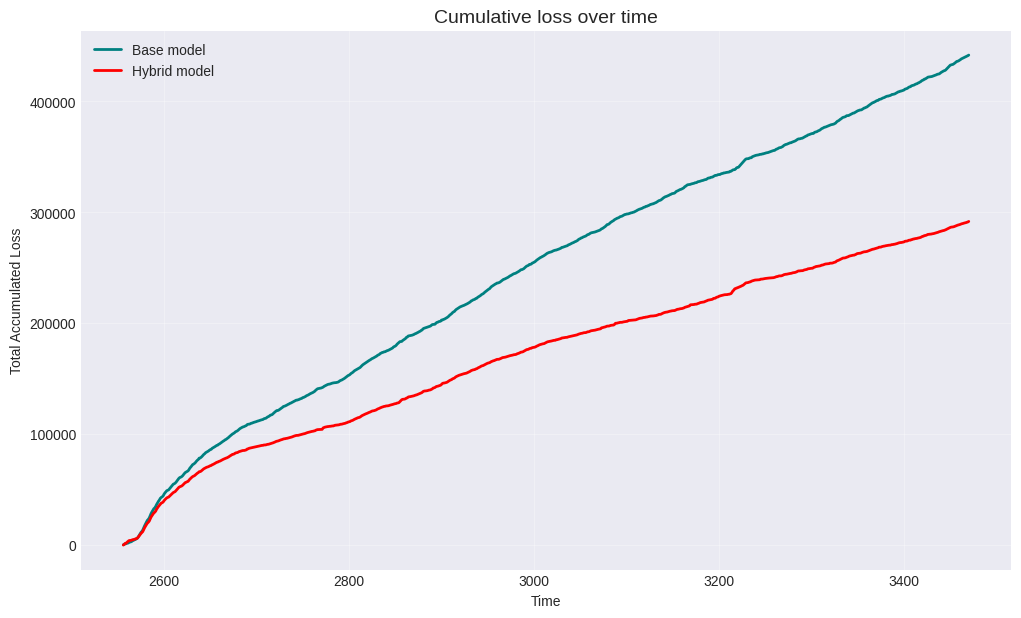

In [15]:
alpha = 0.8
individual_loss_base = np.maximum(alpha * res_val, (alpha - 1) * res_val)
individual_loss = np.maximum(alpha * hybrid_res, (alpha - 1) * hybrid_res)

# Calculate the Running Total (Cumulative)

cumulative_loss_base = np.cumsum(individual_loss_base)
cumulative_loss = np.cumsum(individual_loss)

total_steps = len(cumulative_loss)
average_line = np.linspace(0, cumulative_loss.iloc[-1], total_steps)

# print(cumulative_loss.iloc[-1]/total_steps)

y = cumulative_loss
# connect first and last point
x = np.arange(len(cumulative_loss))
y_line = np.linspace(cumulative_loss.iloc[0], cumulative_loss.iloc[-1], len(cumulative_loss))

fig, ax1 = plt.subplots(1, 1, figsize=(12, 7), sharex=True, facecolor='white')

plt.title('Cumulative loss over time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Total Accumulated Loss')

ax1.plot(X_val['Time'], cumulative_loss_base, label=f'Base model', color='teal', lw=2)
ax1.plot(X_val['Time'], cumulative_loss, label=f'Hybrid model', color='red', lw=2)

ax1.grid(True, alpha=0.3)
ax1.legend()
plt.show()


In [16]:
# Kalman parameters
Q_FINAL = 1 # trust the measurements as much
R_FINAL = 1 # as we trust the predictions
BIAS_SHIFT = np.mean(hybrid_train_res) # our past estimations have bias

kalman = AdaptiveKalman(Q_FINAL,R_FINAL, BIAS_SHIFT, quantile=0.8)
preds_cal = model.predict(X_cal_scaled) + corr_model.predict(X_cal_scaled)
kalman.calibrate(preds_cal, y_cal)
preds_val_raw = model.predict(X_val_scaled) + corr_model.predict(X_val_scaled)

last_val = X_cal_scaled[-1].reshape(1, -1)
last_pred = model.predict(last_val)[0] + corr_model.predict(last_val)[0]

lag_y_val = y_val
preds_val = []
for x, y_today in zip(X_val_scaled, lag_y_val):
    # get current features and actual value
    x_val = x.reshape(1, -1)

    # raw prediction (linear + gbm) for today
    pred_base_today = model.predict(x_val)[0] + corr_model.predict(x_val)[0]

    # update the filter for the next iteration
    final_pred = pred_base_today + kalman.BIAS_SHIFT + kalman.bias
    preds_val.append(final_pred)

    # update the filter for the next iteration
    kalman.update(y_today, pred_base_today)

print("Validation pinball loss :", pinball_loss(y_val, preds_val_raw, 0.8))
print("Validation pinball loss after Kalman filter:", pinball_loss(y_val, preds_val, 0.8))

print(f"Final Bias: {kalman.bias}")
print(f"Kalman Shift: {kalman.BIAS_SHIFT}")


Validation pinball loss : 318.8389586166672
Validation pinball loss after Kalman filter: 263.35630525211724
Final Bias: -1171.4463543872248
Kalman Shift: -96.80438763444775


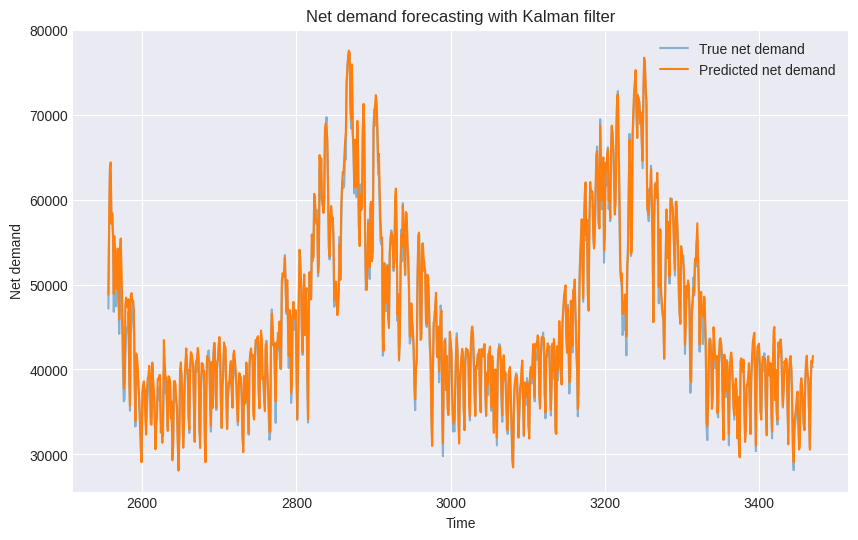

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(X_val['Time'], y_val, label='True net demand',alpha=0.5)
plt.plot(X_val['Time'], preds_val, label= 'Predicted net demand')
plt.xlabel("Time")
plt.ylabel("Net demand")
plt.title("Net demand forecasting with Kalman filter")

plt.legend()
plt.show()

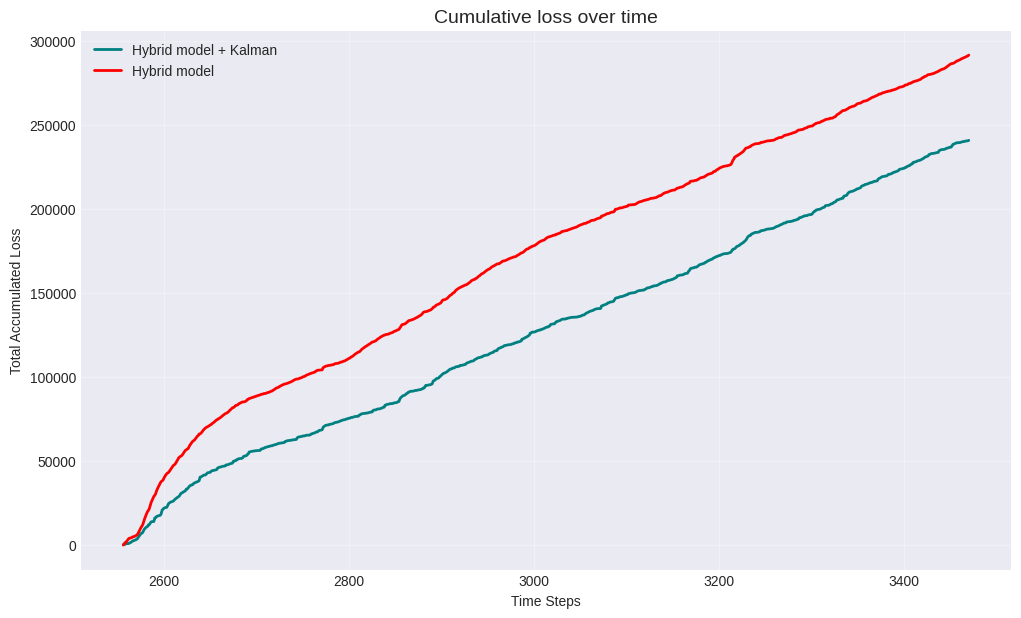

In [18]:
res_kalman = y_val - preds_val
individual_loss = np.maximum(alpha * res_kalman, (alpha - 1) * res_kalman)
# Calculate the running total (cumulative)
cumulative_loss_kalman = np.cumsum(individual_loss)

total_steps = len(cumulative_loss_kalman)
average_line = np.linspace(0, cumulative_loss_kalman.iloc[-1], total_steps)

# print(cumulative_loss.iloc[-1]/total_steps)

y = cumulative_loss_kalman
# connect first and last point
x = np.arange(len(cumulative_loss_kalman))
y_line = np.linspace(cumulative_loss_kalman.iloc[0], cumulative_loss_kalman.iloc[-1], len(cumulative_loss_kalman))

plt.figure(figsize=(12, 7))
plt.plot(X_val['Time'], cumulative_loss_kalman, label=f'Hybrid model + Kalman', color='teal', lw=2)
plt.plot(X_val['Time'], cumulative_loss, label=f'Hybrid model', color='red', lw=2)
# plt.plot(X_val['Time'], y_line, label='Error rate with perfect consistency', color='grey', linestyle='--', alpha=0.7)

plt.title('Cumulative loss over time', fontsize=14)
plt.xlabel('Time Steps')
plt.ylabel('Total Accumulated Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()